# **🤖 Modelo Baseline**

Primer acercamiento para medir **cuánta señal predictiva tienen los datos**, sin feature engineering ni búsqueda de hiperparámetros. Se comparan:

1. **Score**: la variable `score` usada directamente para ordenar las transacciones por riesgo. Es la señal individual más fuerte del dataset y sirve como referencia a superar.
2. **LightGBM** (modelo principal): parámetros por defecto y todas las variables. Maneja nulos y categóricas de forma nativa, así que no requiere preprocesamiento.
3. **LightGBM sin score** (análisis de sensibilidad): el mismo modelo sin `score`, para medir cuánto depende el resultado de esa variable.

**Supuesto sobre `score`**: como todas las variables del dataset, se asume que está disponible al momento de decidir sobre la transacción. No se sabe qué mide (podría ser un score del usuario o de la transacción), pero el análisis de leakage del notebook de exploración no encontró señales de que reproduzca la etiqueta de fraude. El modelo sin score cuantifica el riesgo de ese supuesto: cuánto se perdería si en producción `score` no estuviera disponible a tiempo.

La métrica principal es la **ganancia**: +25% del monto por cada transacción legítima aprobada y −100% del monto por cada fraude aprobado. Todos los modelos se evalúan con **validación cruzada estratificada de 5 folds**.

## **📚 Librerías**

In [1]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Modelado y métricas
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold

# Librerías de visualización
import plotly.express as px
import plotly.io as pio

In [2]:
# Gráficos interactivos en el editor y PNG estático para GitHub y el informe
pio.renderers.default = 'plotly_mimetype+png'
pio.templates.default = 'plotly_white'

COLOR_PRINCIPAL = '#2a78d6'
COLORES_MODELO = {
    'Aprobar todo': '#898781',
    'Score': '#2a78d6',
    'LightGBM': '#eb6834',
    'LightGBM sin score': '#1baf7a',
}

# Parámetros del negocio y del experimento
MARGEN_GANANCIA = 0.25
SEMILLA = 42
NUMERO_FOLDS = 5

In [3]:
# Funciones de ganancia: la decisión es aprobar si la probabilidad de fraude es menor al umbral


def calcular_ganancia(fraude, monto, aprobada):
    """Ganancia total: +25% del monto por legítima aprobada, -100% por fraude aprobado y 0 si se rechaza."""
    fraude = np.asarray(fraude)
    monto = np.asarray(monto)
    aprobada = np.asarray(aprobada)
    ganancia_legitimas = MARGEN_GANANCIA * monto[aprobada & (fraude == 0)].sum()
    perdida_fraudes = monto[aprobada & (fraude == 1)].sum()
    return ganancia_legitimas - perdida_fraudes


def curva_ganancia(fraude, monto, probabilidad, umbrales):
    """Ganancia obtenida con cada umbral de decisión."""
    probabilidad = np.asarray(probabilidad)
    return pd.DataFrame({
        'umbral': umbrales,
        'ganancia': [calcular_ganancia(fraude, monto, probabilidad < umbral) for umbral in umbrales],
    })


def metricas_decision(fraude, monto, aprobada):
    """Resultado de negocio de una decisión: ganancia relativa a la máxima posible, aprobación y detección."""
    fraude = np.asarray(fraude)
    aprobada = np.asarray(aprobada)
    ganancia_maxima = calcular_ganancia(fraude, monto, fraude == 0)
    return {
        '% de la ganancia máxima': calcular_ganancia(fraude, monto, aprobada) / ganancia_maxima * 100,
        '% aprobadas': aprobada.mean() * 100,
        '% fraudes detectados': (~aprobada[fraude == 1]).mean() * 100,
    }

## **🔢 Datos**

In [4]:
# Carga del dataset: fecha como datetime y columnas de texto como categoría para LightGBM
df = pd.read_csv('../data/raw/dataset.csv', parse_dates=['fecha'])

columnas_categoricas = ['g', 'j', 'o', 'p']
df[columnas_categoricas] = df[columnas_categoricas].astype('category')

In [5]:
# Variables del modelo principal: todas salvo el target y la fecha.
# La versión sin score se usa en el análisis de sensibilidad
features = df.columns.drop(['fraude', 'fecha']).tolist()
features_sin_score = [columna for columna in features if columna != 'score']
features

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'monto',
 'score']

## **🔁 Esquema de validación**

Antes de evaluar los modelos hay que decidir cómo validar. Si el comportamiento del fraude cambiara en el tiempo, lo correcto sería un esquema temporal (entrenar con el pasado y validar con el futuro). Si en cambio cada transacción es independiente y comparable sin importar su fecha, una CV aleatoria es válida y aprovecha mejor los datos. Para decidir con evidencia, se evalúa el LightGBM principal con ambos esquemas:

- **Aleatoria**: 5 folds estratificados que mezclan todas las fechas.
- **Temporal**: ventana expansiva semanal, donde cada fold entrena con las semanas anteriores y valida en la siguiente.

Si los resultados son parecidos, las transacciones se comportan como independientes del tiempo. Si el temporal da claramente peor, hay dependencia temporal y el CV aleatorio sobreestima el rendimiento. Para que la comparación no dependa de cómo se elige el umbral, se usa en ambos casos el **umbral teórico de 0,2**.

In [6]:
# Umbral teórico: aprobar si p · monto < (1 - p) · 0,25 · monto, es decir p < 0,25 / 1,25
UMBRAL_TEORICO = MARGEN_GANANCIA / (1 + MARGEN_GANANCIA)


def evaluar_fold(datos_train, datos_validacion):
    """Entrena LightGBM por defecto en un fold y devuelve sus métricas en validación con el umbral teórico."""
    modelo = lgb.LGBMClassifier(random_state=SEMILLA, verbose=-1)
    modelo.fit(datos_train[features], datos_train['fraude'])
    probabilidad = modelo.predict_proba(datos_validacion[features])[:, 1]

    fraude = datos_validacion['fraude']
    return {
        'transacciones train': len(datos_train),
        'auc_roc': roc_auc_score(fraude, probabilidad),
        'auc_pr': average_precision_score(fraude, probabilidad),
        '% de la ganancia máxima': metricas_decision(
            fraude, datos_validacion['monto'], probabilidad < UMBRAL_TEORICO
        )['% de la ganancia máxima'],
    }

In [7]:
# CV aleatoria estratificada. Estos mismos folds se reutilizan después para evaluar todos los modelos
folds = list(
    StratifiedKFold(n_splits=NUMERO_FOLDS, shuffle=True, random_state=SEMILLA).split(df, df['fraude'])
)
resultados_aleatoria = pd.DataFrame([
    evaluar_fold(df.iloc[indices_train], df.iloc[indices_validacion])
    for indices_train, indices_validacion in folds
]).assign(esquema='Aleatoria')
resultados_aleatoria.round(3)

,transacciones train,auc_roc,auc_pr,% de la ganancia máxima,esquema
0,120000,0.864,0.432,76.239,Aleatoria
1,120000,0.882,0.453,78.422,Aleatoria
2,120000,0.870,0.427,79.494,Aleatoria
3,120000,0.873,0.435,77.412,Aleatoria
4,120000,0.873,0.441,75.874,Aleatoria


In [8]:
# CV temporal con ventana expansiva: entrena con las semanas anteriores y valida en la siguiente.
# Los últimos 3 días se suman a la semana 6 para no dejar un fold demasiado chico
semana = ((df['fecha'].dt.normalize() - df['fecha'].min().normalize()).dt.days // 7).clip(upper=5)
resultados_temporal = pd.DataFrame([
    evaluar_fold(df[semana < semana_validacion], df[semana == semana_validacion])
    for semana_validacion in range(2, 6)
]).assign(esquema='Temporal')
resultados_temporal.round(3)

,transacciones train,auc_roc,auc_pr,% de la ganancia máxima,esquema
0,49731,0.861,0.431,75.890,Temporal
1,70666,0.864,0.443,74.036,Temporal
2,87466,0.870,0.447,73.393,Temporal
3,111564,0.870,0.411,79.175,Temporal


In [9]:
# Promedio y desvío estándar de cada métrica según el esquema de validación
metricas_esquema = ['auc_roc', 'auc_pr', '% de la ganancia máxima']
comparacion = pd.concat([resultados_aleatoria, resultados_temporal], ignore_index=True)
comparacion.groupby('esquema')[metricas_esquema].agg(['mean', 'std']).round(3)

auc_roc        auc_pr        % de la ganancia máxima       
             mean    std   mean    std                    mean    std
esquema                                                              
Aleatoria   0.872  0.007  0.437  0.010                  77.488  1.506
Temporal    0.866  0.004  0.433  0.016                  75.624  2.593

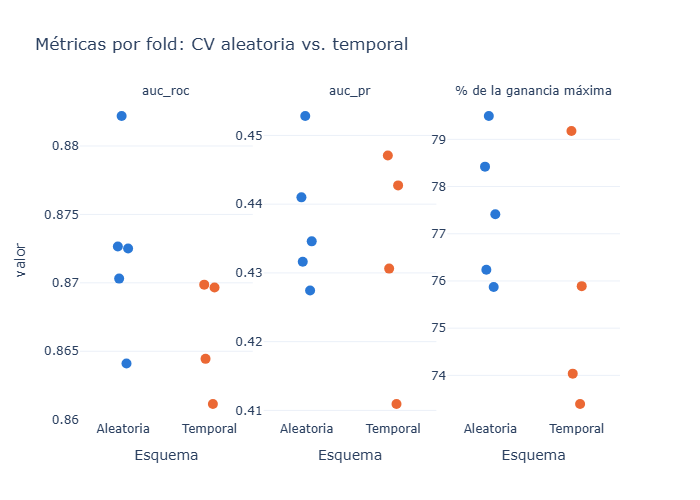

In [10]:
# Resultado de cada fold por esquema y métrica
fig = px.strip(
    comparacion.melt(id_vars='esquema', value_vars=metricas_esquema, var_name='métrica', value_name='valor'),
    x='esquema',
    y='valor',
    color='esquema',
    facet_col='métrica',
    color_discrete_map={'Aleatoria': '#2a78d6', 'Temporal': '#eb6834'},
    labels={'esquema': 'Esquema'},
    title='Métricas por fold: CV aleatoria vs. temporal',
)
fig.update_traces(marker_size=10)
fig.update_yaxes(matches=None, showticklabels=True)
fig.for_each_annotation(lambda anotacion: anotacion.update(text=anotacion.text.split('=')[-1]))
fig.update_layout(showlegend=False)
fig.show()

**💡 Hallazgos**

- **Ambos esquemas dan prácticamente lo mismo en ranking**: el AUC-ROC es de 0,872 en la aleatoria y 0,866 en la temporal, y el AUC-PR de 0,437 frente a 0,433. Las diferencias están dentro de la variación normal entre folds.
- En ganancia, la temporal queda ~1,9 puntos por debajo (75,6% frente a 77,5% de la ganancia máxima), una diferencia menor que su desvío entre folds (2,6 puntos). No depende de cuántos datos ve el modelo: el fold entrenado con solo 2 semanas (75,9%) rinde mejor que el entrenado con 4 (73,4%). Tiene más que ver con qué semana se valida (cada semana tiene su propia mezcla de tasa de fraude y montos) que con un deterioro del modelo.
- Incluso el primer fold temporal, entrenado con solo 2 semanas, llega a un AUC de 0,861. **El modelo no pierde capacidad de ranking al predecir semanas que no vio**, aunque la tasa de fraude cambie entre semanas (4,5% a 5,9%).
- Conclusión: **no hay evidencia de dependencia temporal fuerte**, así que en adelante se usa **CV aleatoria estratificada**: aprovecha todos los datos en cada fold y da estimaciones más estables. Como la ganancia sí varía según la semana, conviene reportarla siempre con su desvío y no como un número único.

## **🤖 Modelos**

In [11]:
# Referencia: score reescalado a [0, 1] para ordenar las transacciones por riesgo (no requiere entrenamiento)
probabilidades = {'Score': (df['score'] / 100).to_numpy()}

In [12]:
# LightGBM por defecto: el principal con todas las variables y la versión sin score para el análisis de sensibilidad.
# Cada transacción recibe la predicción del modelo que no la vio en entrenamiento (predicción out-of-fold)
modelos = {}
for nombre_modelo, columnas in [('LightGBM', features), ('LightGBM sin score', features_sin_score)]:
    probabilidad_oof = np.zeros(len(df))
    modelos[nombre_modelo] = []
    for indices_train, indices_validacion in folds:
        modelo = lgb.LGBMClassifier(random_state=SEMILLA, verbose=-1)
        modelo.fit(df.iloc[indices_train][columnas], df['fraude'].iloc[indices_train])
        probabilidad_oof[indices_validacion] = modelo.predict_proba(df.iloc[indices_validacion][columnas])[:, 1]
        modelos[nombre_modelo].append(modelo)
    probabilidades[nombre_modelo] = probabilidad_oof

## **📊 Evaluación**

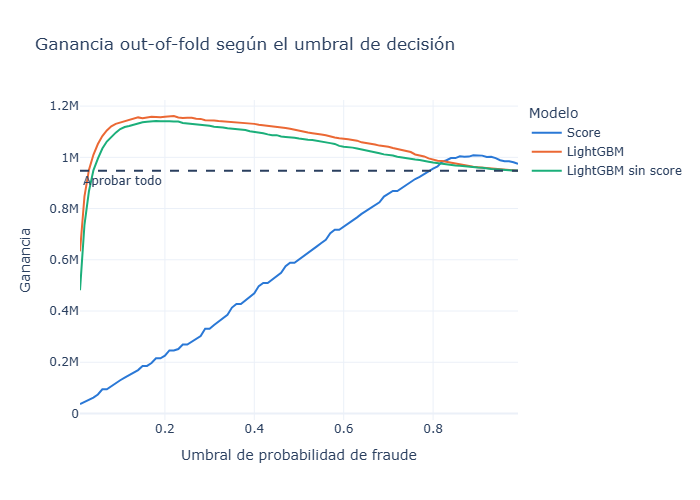

In [13]:
# Curva de ganancia con las predicciones out-of-fold de todo el dataset: el umbral óptimo de cada modelo se elige aquí.
# Es un único parámetro elegido sobre 150k transacciones, así que el sesgo optimista es mínimo
umbrales = np.linspace(0.01, 0.99, 99)
curvas = pd.concat(
    [
        curva_ganancia(df['fraude'], df['monto'], probabilidad, umbrales).assign(modelo=nombre_modelo)
        for nombre_modelo, probabilidad in probabilidades.items()
    ],
    ignore_index=True,
)
umbrales_optimos = curvas.loc[curvas.groupby('modelo')['ganancia'].idxmax()].set_index('modelo')['umbral']

fig = px.line(
    curvas,
    x='umbral',
    y='ganancia',
    color='modelo',
    color_discrete_map=COLORES_MODELO,
    labels={'umbral': 'Umbral de probabilidad de fraude', 'ganancia': 'Ganancia', 'modelo': 'Modelo'},
    title='Ganancia out-of-fold según el umbral de decisión',
)
fig.add_hline(
    y=calcular_ganancia(df['fraude'], df['monto'], np.ones(len(df), dtype=bool)),
    line_dash='dash',
    annotation_text='Aprobar todo',
    annotation_position='bottom left',
)
fig.show()

In [14]:
# Umbral óptimo de cada modelo
umbrales_optimos

modelo
LightGBM              0.22
LightGBM sin score    0.20
Score                 0.90
Name: umbral, dtype: float64

**💡 Hallazgos**

- El **score necesita un umbral de 0,90**: solo conviene rechazar las transacciones con score ≥ 90. `score` no es una probabilidad calibrada, así que su umbral hay que buscarlo con la curva de ganancia.
- El umbral óptimo del **LightGBM (0,22)** es casi el teórico: si la probabilidad fuera exacta, conviene aprobar mientras `p · monto < (1 − p) · 0,25 · monto`, es decir `p < 0,2`. Esto sugiere que las probabilidades del modelo están razonablemente calibradas. Sin score, el óptimo coincide exactamente (0,20).
- La curva de LightGBM es **plana alrededor del óptimo** (entre ~0,1 y 0,3 la ganancia casi no cambia), así que un error en la elección del umbral cuesta poco. La del score tiene un pico más angosto y es más sensible al umbral.

In [15]:
# Métricas de cada modelo en cada fold con su umbral óptimo; aprobar todo se incluye como referencia sin modelo
filas = []
for numero_fold, (_, indices_validacion) in enumerate(folds, start=1):
    fraude = df['fraude'].iloc[indices_validacion].to_numpy()
    monto = df['monto'].iloc[indices_validacion].to_numpy()
    filas.append({
        'modelo': 'Aprobar todo',
        'fold': numero_fold,
        **metricas_decision(fraude, monto, np.ones(len(fraude), dtype=bool)),
    })
    for nombre_modelo, probabilidad in probabilidades.items():
        probabilidad_fold = probabilidad[indices_validacion]
        filas.append({
            'modelo': nombre_modelo,
            'fold': numero_fold,
            'auc_roc': roc_auc_score(fraude, probabilidad_fold),
            'auc_pr': average_precision_score(fraude, probabilidad_fold),
            **metricas_decision(fraude, monto, probabilidad_fold < umbrales_optimos[nombre_modelo]),
        })

metricas_por_fold = pd.DataFrame(filas)
resumen = metricas_por_fold.drop(columns='fold').groupby('modelo', sort=False).agg(['mean', 'std'])
resumen.round(3)

% de la ganancia máxima        % aprobadas         \
                                      mean    std        mean    std   
modelo                                                                 
Aprobar todo                        63.400  1.871     100.000  0.000   
Score                               67.428  1.233      91.499  0.186   
LightGBM                            77.660  1.679      94.740  0.107   
LightGBM sin score                  76.363  1.124      94.669  0.243   

                   % fraudes detectados        auc_roc        auc_pr         
                                   mean    std    mean    std   mean    std  
modelo                                                                       
Aprobar todo                       0.00  0.000     NaN    NaN    NaN    NaN  
Score                             38.48  1.253   0.726  0.011  0.177  0.008  
LightGBM                          44.64  1.072   0.872  0.007  0.437  0.010  
LightGBM sin score                38.92  1.897   0.834  0.006  0.362  0.014

**💡 Hallazgos**

- **Aprobar todo ya obtiene el 63% de la ganancia máxima**, porque el 95% de las transacciones son legítimas. El margen real para mejorar es el 37% restante.
- **LightGBM llega al 77,7% (± 1,7)** de la ganancia máxima, frente al **67,4% (± 1,2) del score**. Recupera el 39% de la ganancia que se pierde por fraude, contra el 11% del score, y lo supera en **los 5 folds**.
- En ranking también es claramente mejor: **AUC-ROC de 0,872 frente a 0,726** y AUC-PR de 0,437 frente a 0,177.
- LightGBM **detecta más fraudes (44,6% frente a 38,5%) y a la vez rechaza menos transacciones** (5,3% frente a 8,5%): es mejor en las dos dimensiones del problema al mismo tiempo.
- **Análisis de sensibilidad**: sin `score`, el modelo llega al 76,4% (± 1,1), solo **1,3 puntos menos**, y sigue superando ampliamente al score en los 5 folds. Si en producción `score` no estuviera disponible a tiempo, la solución seguiría siendo válida: el resto de las variables tiene señal propia.
- La variación entre folds es baja (desvíos de 1–2 puntos), así que las diferencias entre modelos son sólidas y no dependen de la partición.

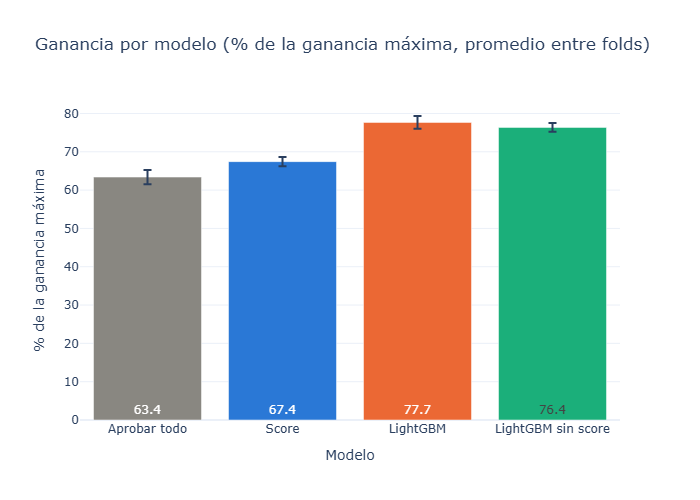

In [16]:
# Ganancia de cada modelo como porcentaje de la ganancia máxima posible (promedio y desvío entre folds)
ganancia_promedio = resumen['% de la ganancia máxima'].reset_index()

fig = px.bar(
    ganancia_promedio,
    x='modelo',
    y='mean',
    error_y='std',
    color='modelo',
    text_auto='.1f',
    color_discrete_map=COLORES_MODELO,
    labels={'modelo': 'Modelo', 'mean': '% de la ganancia máxima'},
    title='Ganancia por modelo (% de la ganancia máxima, promedio entre folds)',
)
fig.update_traces(textposition='inside', insidetextanchor='start')
fig.update_layout(showlegend=False)
fig.show()

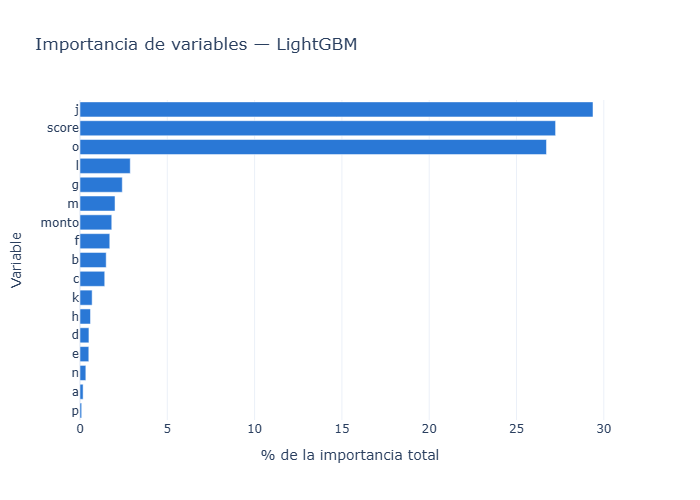

In [17]:
# Importancia de variables del LightGBM principal: ganancia de información promedio entre los modelos de cada fold
importancia = pd.Series(
    np.mean([modelo.booster_.feature_importance(importance_type='gain') for modelo in modelos['LightGBM']], axis=0),
    index=features,
).sort_values()

fig = px.bar(
    importancia / importancia.sum() * 100,
    orientation='h',
    color_discrete_sequence=[COLOR_PRINCIPAL],
    labels={'index': 'Variable', 'value': '% de la importancia total'},
    title='Importancia de variables — LightGBM',
)
fig.update_layout(showlegend=False, height=500)
fig.show()

**💡 Hallazgos**

- `score` (~27%) y `o` (~27%) están entre las variables más importantes, lo que es consistente con la exploración: son las que más separaban las clases. Muy por detrás aparecen `l`, `g` y `m`.
- ⚠️ **`j` aparece como la variable más importante (~29%)**, a pesar de tener 8.324 categorías. Con categóricas de tan alta cardinalidad, LightGBM puede **memorizar categorías vistas en train**, y la importancia por ganancia tiende a inflarse. Hay que verificarlo en la etapa de feature engineering, comparando el modelo con y sin `j` o con otro encoding (frecuencia o target encoding).
- `a`, `n` y `p` casi no aportan una vez que el modelo tiene el resto. Su información probablemente ya está contenida en otras variables.

**🧭 Conclusiones del baseline**

- La comparación entre CV aleatoria y temporal da un ranking equivalente: las transacciones se comportan como **independientes del tiempo**, así que la CV aleatoria estratificada es un esquema de validación válido.
- Los datos tienen **señal predictiva suficiente**: un LightGBM por defecto supera al score en ganancia (+10 puntos de la ganancia máxima) y en capacidad de ranking, de forma consistente en todos los folds.
- `score` se incluye bajo el **supuesto de que está disponible al momento de decidir**, respaldado por el análisis de leakage de la exploración. El modelo es robusto a ese supuesto: sin `score` pierde solo 1,3 puntos.
- Optimizar el **umbral por ganancia** es tan importante como el modelo: con el mismo score, el umbral decide si se gana o se pierde frente a aprobar todo.
- Puntos a trabajar en las siguientes etapas: validar el efecto de `j`, feature engineering (nulos informativos, agrupación de países, variables temporales), búsqueda de hiperparámetros y revisión de la calibración de las probabilidades.